In [2]:
# if the current working directory is src, change it to the parent directory
import os
if os.getcwd().endswith('experimental'):
    os.chdir('../..')

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
from scipy.stats import linregress, gmean
from matplotlib.colors import LogNorm
from types import SimpleNamespace
from numpy.linalg import lstsq

### Read results of powerlaw and lognormal fits

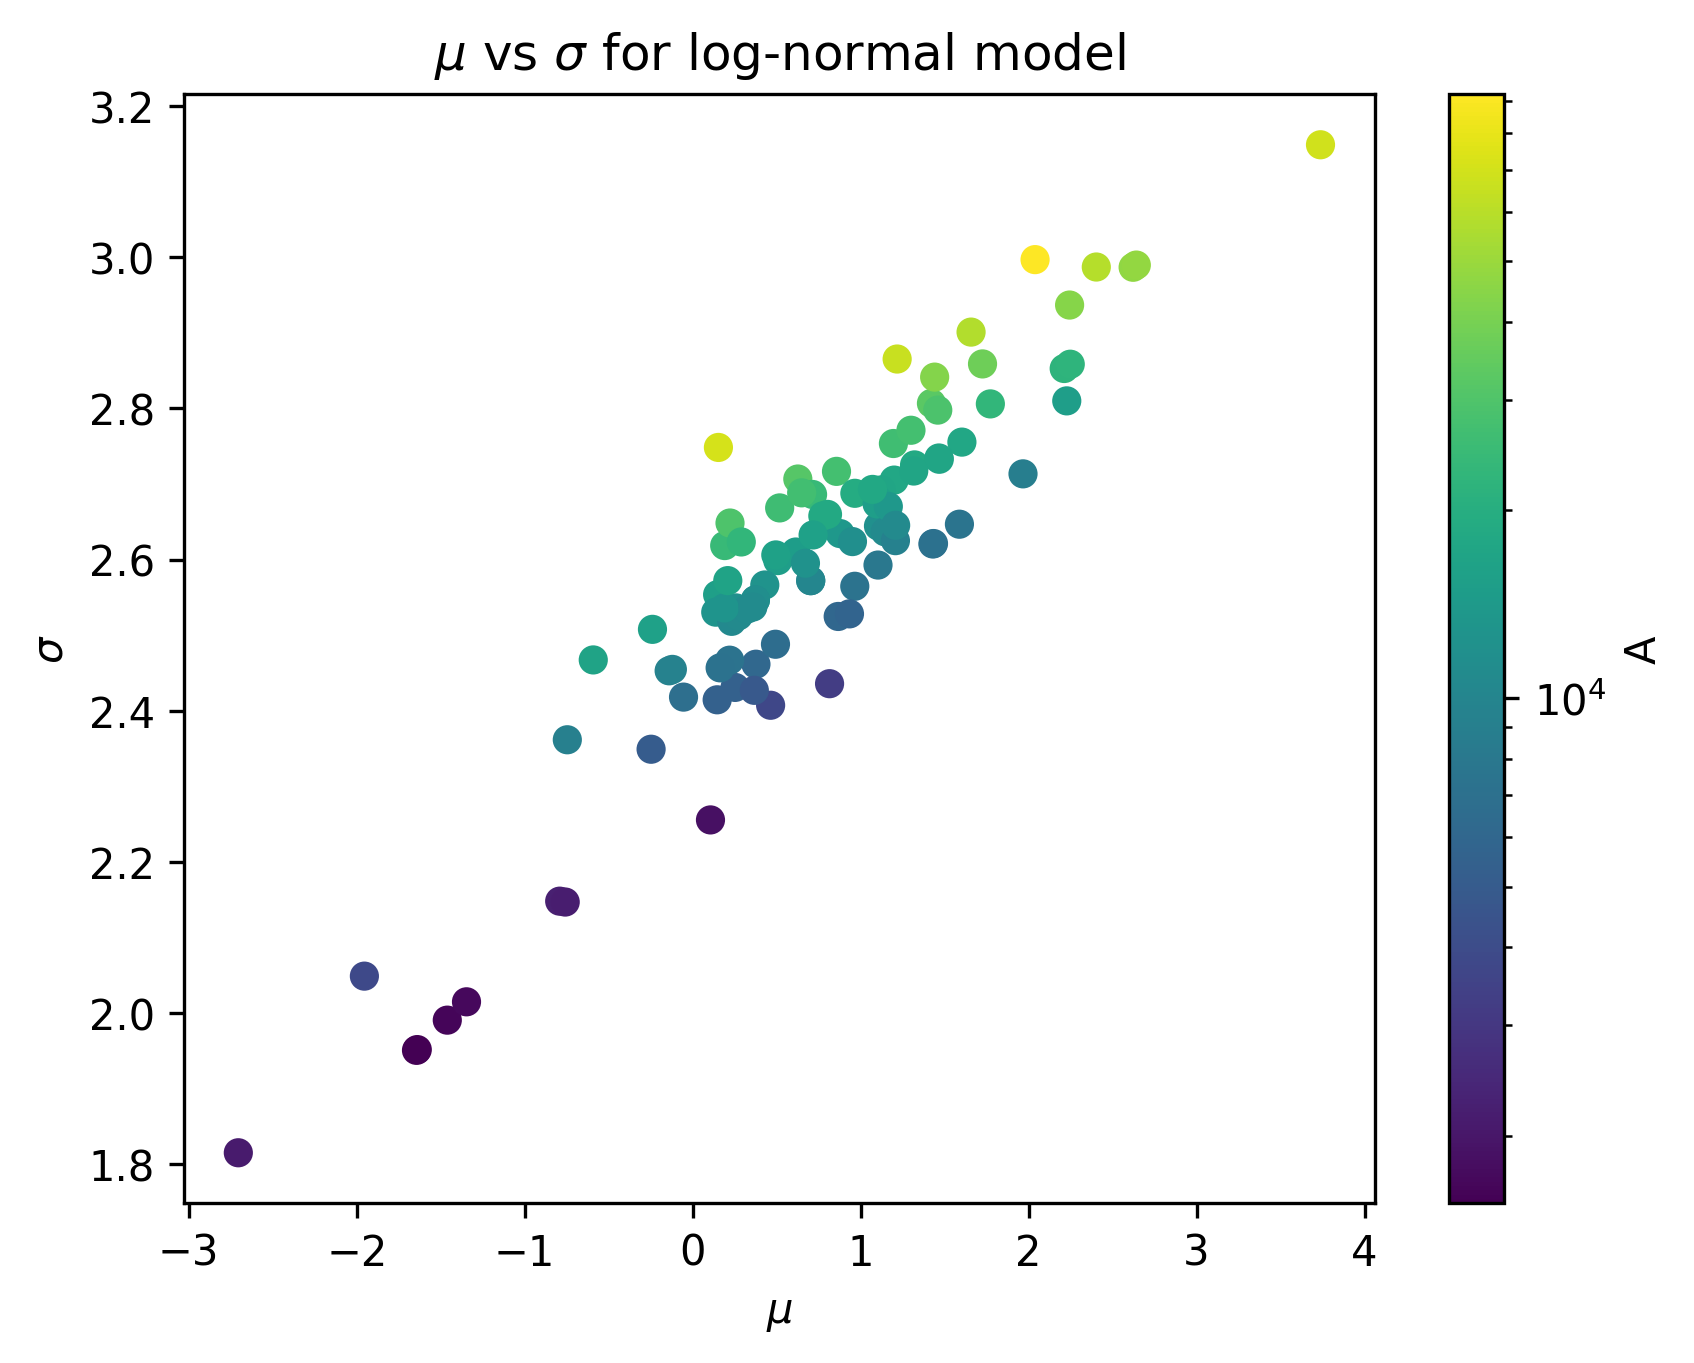

In [26]:
# load data
ln = pd.read_csv('results/03_calibrate_models/03b_lognormal_predictions_calcurve.csv')

# convert lognromal parameters to mean and std
ln['sigma'] = np.sqrt(np.log(ln['pred'] / ln['turnover']))
ln['mu'] = -np.log(np.sqrt(ln['turnover']**3 / ln['pred']))

fig, ax = plt.subplots(dpi=300)

# make the colorbar with log scale
scatter = ax.scatter(ln['mu'], ln['sigma'], c=ln['pred'], cmap='viridis', norm=LogNorm())
ax.set(xlabel='$\mu$', ylabel='$\sigma$', title='$\mu$ vs $\sigma$ for log-normal model')
plt.colorbar(scatter, label='A')

In [27]:
ln

,Latitude,Longitude,14C,NPP,Ctotal_0-100estim,Ctotal_0-100estim_q05,Ctotal_0-100estim_q95,fm,turnover,turnover_q05,turnover_q95,pred,pred_05,pred_95,sigma,mu
0,-28.666667,153.333333,-86.772427,1388.552,18.791450,5.328919,35.900084,0.913228,13.533127,3.837752,25.854331,10108.432910,21822.748742,6847.162097,2.572156,0.702852
1,-28.666667,153.333333,-86.772427,1388.552,18.791450,5.328919,35.900084,0.913228,13.533127,3.837752,25.854331,10108.432910,21822.748742,6847.162097,2.572156,0.702852
2,-27.983333,148.550000,-158.831513,258.568,4.399100,NaN,NaN,0.841168,17.013320,NaN,NaN,27301.854197,NaN,NaN,2.716747,0.856360
3,-26.583333,151.833333,-133.147675,991.436,22.274269,NaN,NaN,0.866852,22.466674,NaN,NaN,15262.085428,NaN,NaN,2.553643,0.148514
4,-23.216667,143.950000,-162.928691,138.920,5.268076,NaN,NaN,0.837071,37.921649,NaN,NaN,16695.433415,NaN,NaN,2.467259,-0.591838
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,51.500000,11.983333,-128.036384,574.808,10.457876,NaN,NaN,0.871964,18.193686,NaN,NaN,16208.452035,NaN,NaN,2.606188,0.495032
95,52.350000,13.316667,-79.478734,597.252,5.901218,NaN,NaN,0.920521,9.880617,NaN,NaN,10814.483120,NaN,NaN,2.645386,1.208458
96,52.850000,-6.900000,-58.617974,560.932,11.341396,NaN,NaN,0.941382,20.218842,NaN,NaN,5038.454349,NaN,NaN,2.349093,-0.247495
97,56.833333,9.433333,-120.839749,713.240,9.178798,NaN,NaN,0.879160,12.869158,NaN,NaN,18148.821672,NaN,NaN,2.692866,1.070930


Fitting bin (1559.465, 2454.309] with 7 points
Bin (1559.465, 2454.309] midpoint: 1869.1608526941175, slope: 1.4982271752895708, ln_midpoint: 7.533244867259063
Skipping bin (2454.309, 3862.628] with 3 points
Fitting bin (3862.628, 6079.062] with 7 points
Bin (3862.628, 6079.062] midpoint: 5380.438943161992, slope: 1.4964113550860603, ln_midpoint: 8.59052523777604
Fitting bin (6079.062, 9567.32] with 14 points
Bin (6079.062, 9567.32] midpoint: 7930.903510852528, slope: 1.5011187049799768, ln_midpoint: 8.978522243933474
Fitting bin (9567.32, 15057.191] with 21 points
Bin (9567.32, 15057.191] midpoint: 12320.74943749224, slope: 1.5041386158690913, ln_midpoint: 9.419040066202662
Fitting bin (15057.191, 23697.234] with 24 points
Bin (15057.191, 23697.234] midpoint: 18593.36020935869, slope: 1.505933763731188, ln_midpoint: 9.830559817978013
Fitting bin (23697.234, 37295.063] with 11 points
Bin (23697.234, 37295.063] midpoint: 28137.98434145759, slope: 1.501983690848714, ln_midpoint: 10.24487

/var/folders/yf/tm7rdp795tg2kszdyntdjl6r0000gn/T/ipykernel_26326/105719739.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in ln.groupby('A_bin'):


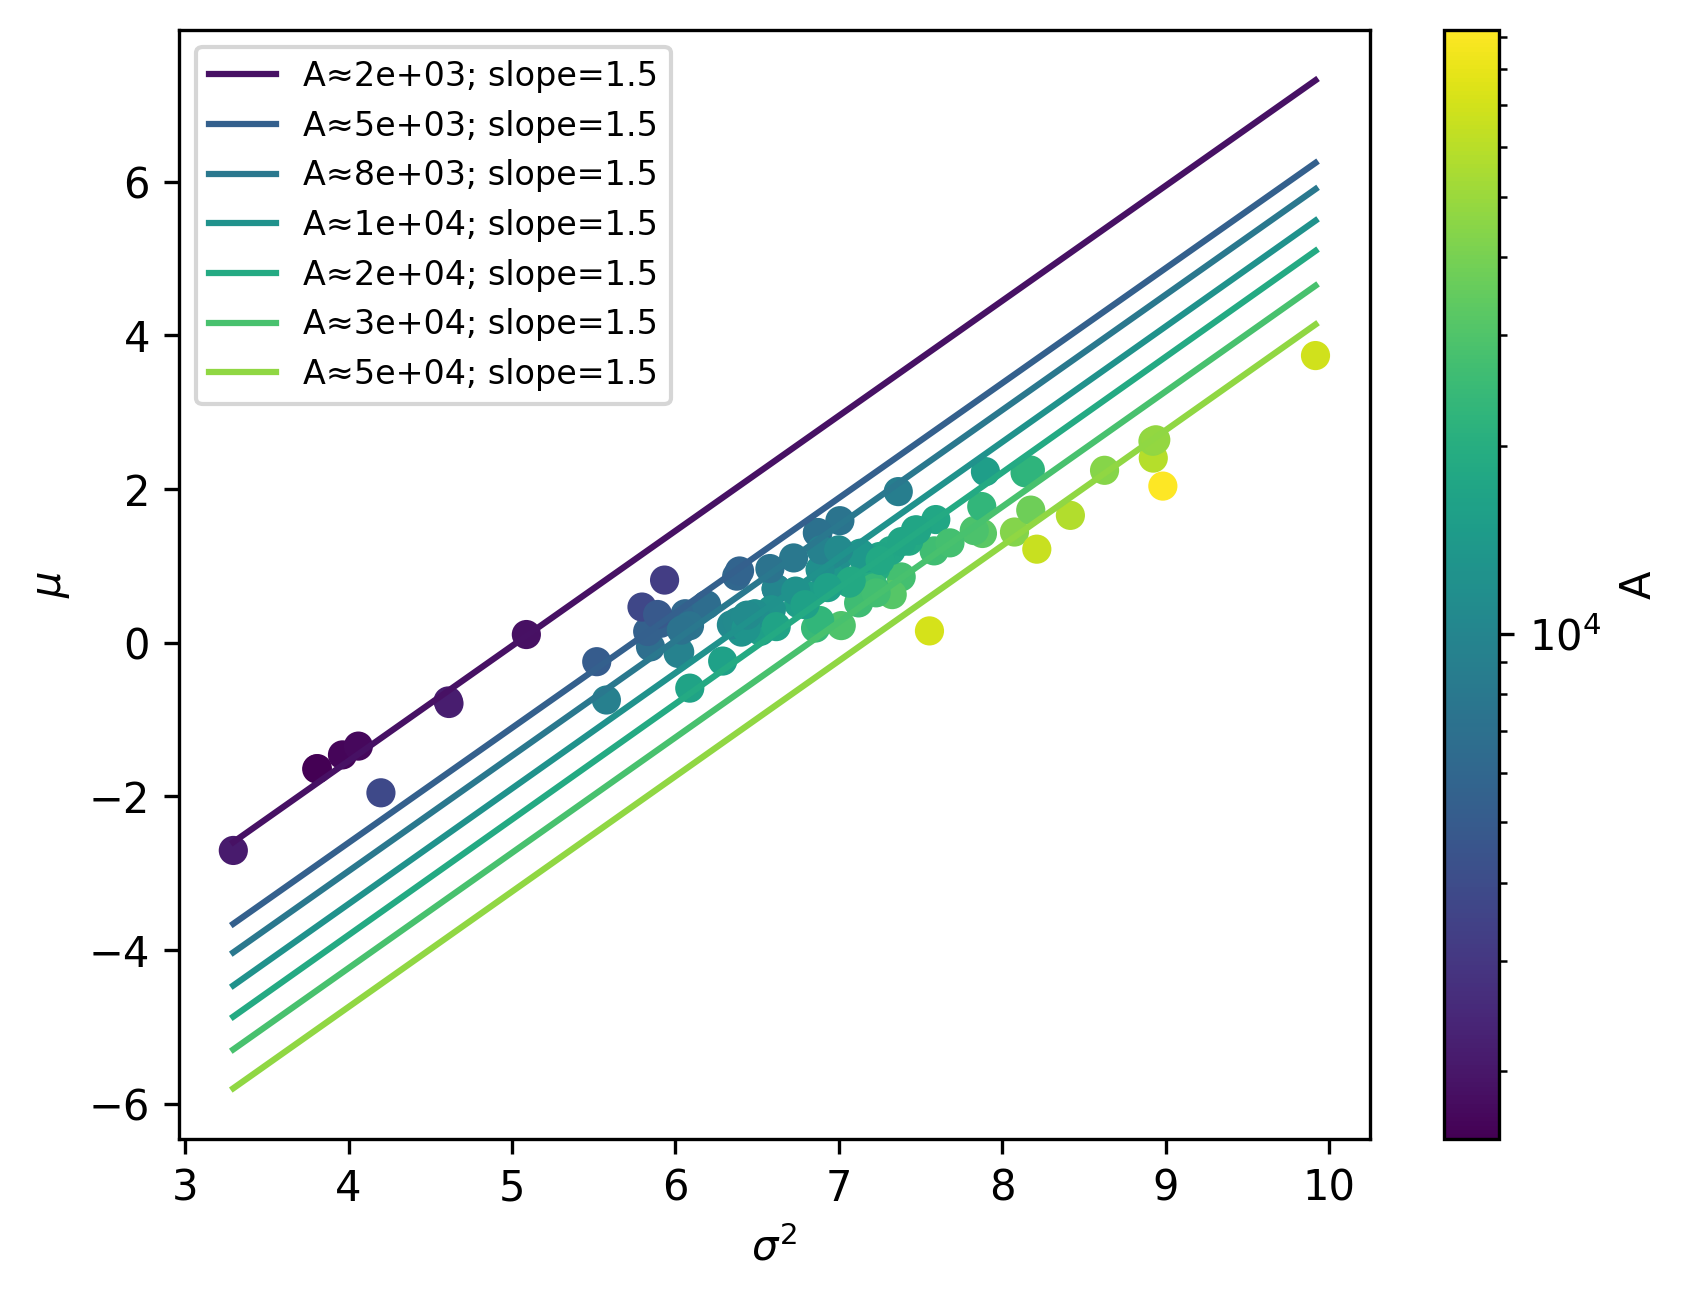

In [48]:
# Bin by A  
bins = np.logspace(np.log10(ln['pred'].min()), np.log10(ln['pred'].max()), 10)
ln['A_bin'] = pd.cut(ln['pred'], bins=bins)
# For each bin, fit a line to sigma^2 vs mu
bin_fits = {}
for name, group in ln.groupby('A_bin'):
    if len(group) <= 5:
        print(f"Skipping bin {name} with {len(group)} points")
        continue
    print(f"Fitting bin {name} with {len(group)} points")
    bin_midpoint = gmean([group['pred'].min(), group['pred'].max()])
    ln_midpoint = np.log(bin_midpoint)
    # fit mu + ln_midpoint = slope * sigma^2 with no intercept using lstsq
    x = (group['sigma']**2).to_numpy()
    y = (group['mu'] + ln_midpoint).to_numpy()
    slope = np.linalg.lstsq(x[:, None], y, rcond=None)[0].item()
    res = SimpleNamespace(slope=slope, ln_midpoint=ln_midpoint)

    print(f"Bin {name} midpoint: {bin_midpoint}, slope: {res.slope}, ln_midpoint: {res.ln_midpoint}")
    bin_fits[bin_midpoint] = res

# Plot sigma^2 vs mu
fig, ax = plt.subplots(dpi=300)
my_norm = LogNorm(vmin=ln['pred'].min(), vmax=ln['pred'].max())
scatter = ax.scatter(ln['sigma']**2, ln['mu'], c=ln['pred'], cmap='viridis', norm=my_norm)
ax.set(ylabel='$\\mu$', xlabel='$\\sigma^2$')

for bin_midpoint, res in bin_fits.items():
    sigma2s = np.linspace(ln['sigma'].min()**2, ln['sigma'].max()**2, 100)
    mus = res.slope * sigma2s - res.ln_midpoint
    color = plt.cm.viridis(my_norm(bin_midpoint))
    plt.plot(sigma2s, mus, label=f'A≈{bin_midpoint:.1g}; slope={res.slope:.1f}', color=color)

plt.colorbar(scatter, label='A')
plt.legend(fontsize=8)
plt.show()


Skipping bin (3.386, 4.796] with 0 points
Fitting bin (4.796, 6.793] with 7 points
Bin (4.796, 6.793] midpoint: 6.138843469891065, slope: 0.4998204599604073, ln_midpoint: 1.814636364464492
Fitting bin (6.793, 9.621] with 10 points
Bin (6.793, 9.621] midpoint: 8.431984927274197, slope: 0.49951202716953125, ln_midpoint: 2.132032204235051
Fitting bin (9.621, 13.627] with 31 points
Bin (9.621, 13.627] midpoint: 11.421125129209107, slope: 0.49667716930382627, ln_midpoint: 2.435464722072642
Fitting bin (13.627, 19.301] with 24 points
Bin (13.627, 19.301] midpoint: 16.483032923581884, slope: 0.49703310287217933, ln_midpoint: 2.8023315441737777
Fitting bin (19.301, 27.338] with 16 points
Bin (19.301, 27.338] midpoint: 22.75075023041878, slope: 0.5050508712109486, ln_midpoint: 3.12459812201449
Fitting bin (27.338, 38.72] with 8 points
Bin (27.338, 38.72] midpoint: 33.314600769120425, slope: 0.4973834853975389, ln_midpoint: 3.5059957624253757
Skipping bin (38.72, 54.842] with 0 points
Skipping b

/var/folders/yf/tm7rdp795tg2kszdyntdjl6r0000gn/T/ipykernel_26326/1326987298.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in ln.groupby('T_bin'):


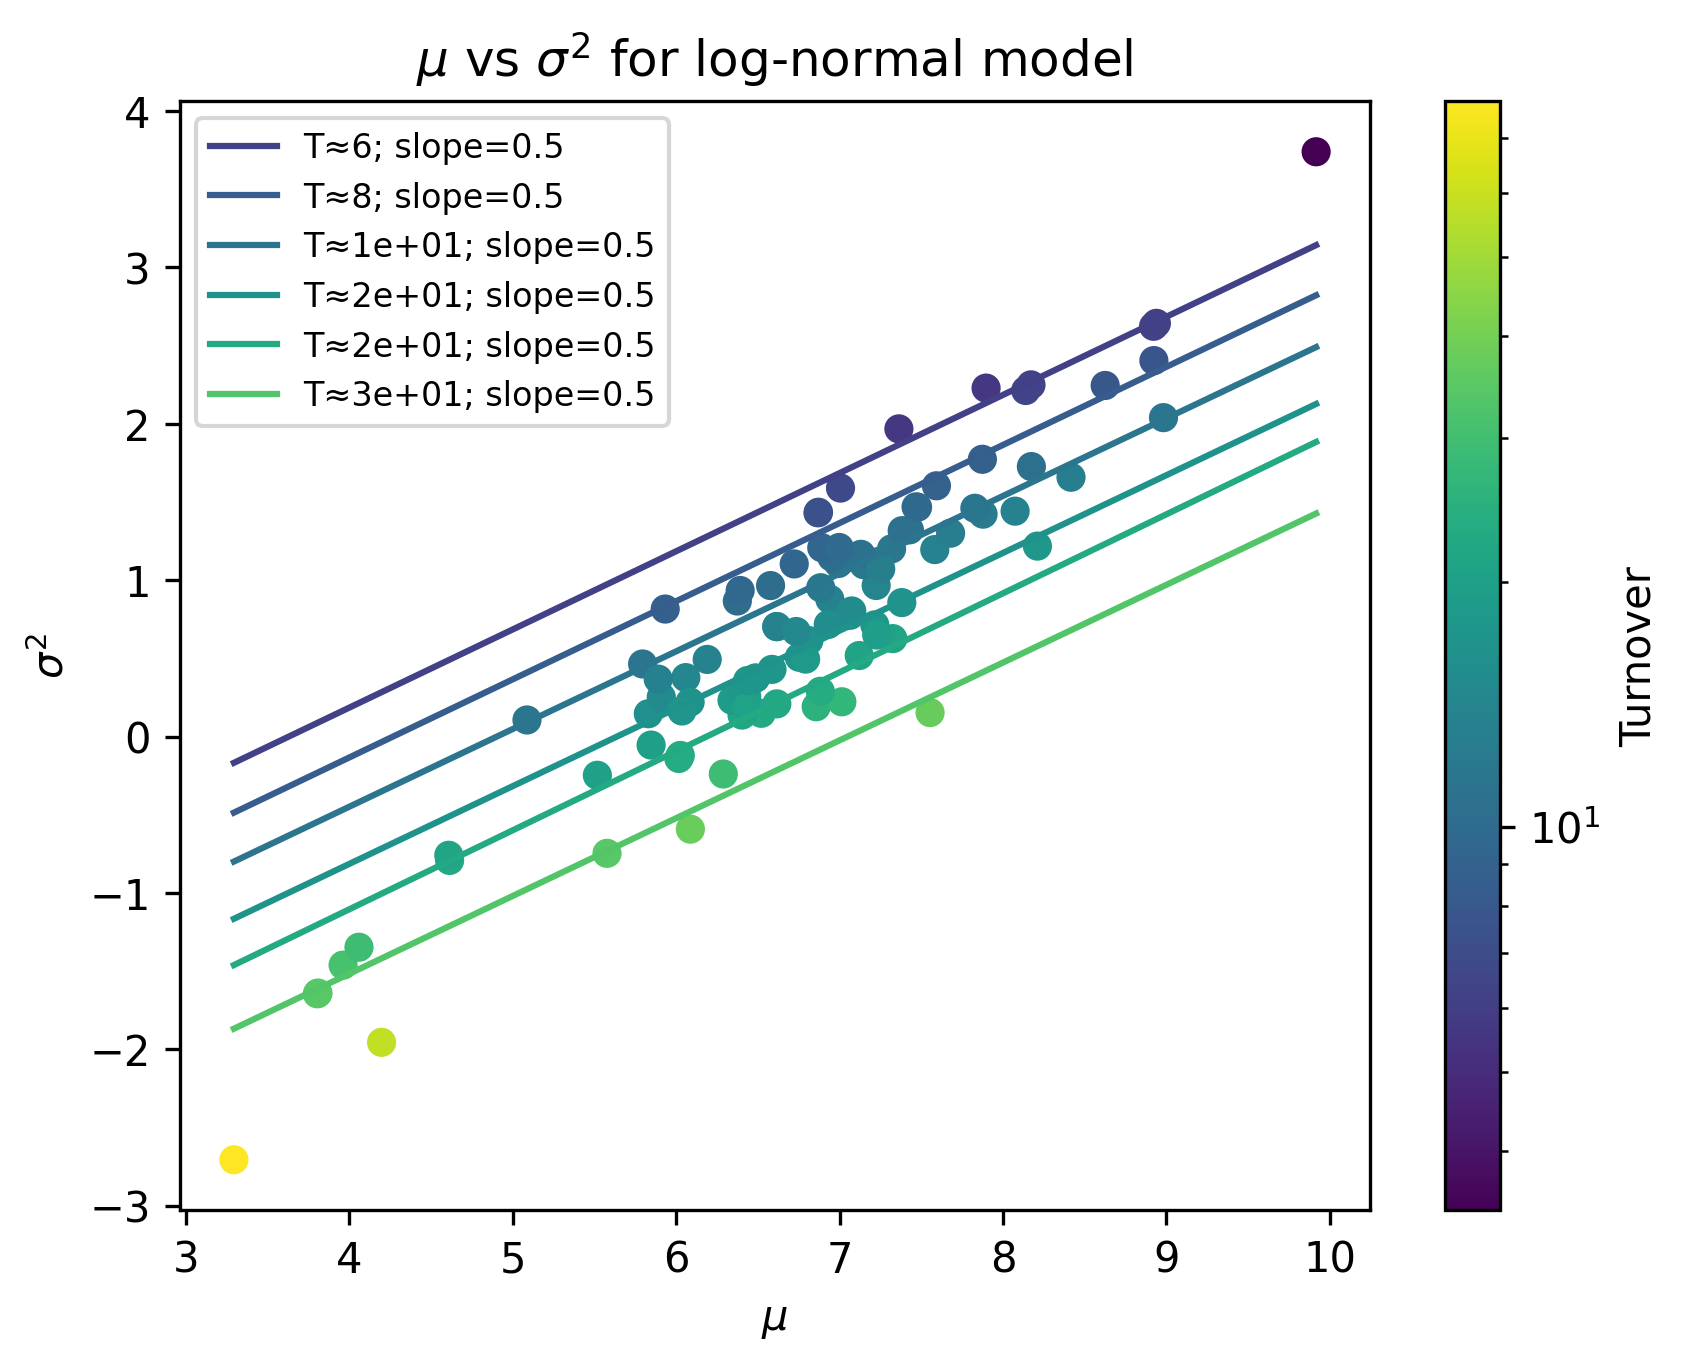

In [53]:
# As noted below, we expect that mu - log(T) = sigma^2/2. Lets bin by turnover and fit the slope.
# Bin by turnover
bins = np.logspace(np.log10(ln['turnover'].min()), np.log10(ln['turnover'].max()), 10)
ln['T_bin'] = pd.cut(ln['turnover'], bins=bins)
# For each bin, fit a line to sigma^2 vs mu
bin_fits = {}

# Copy the same approach as above. 
for name, group in ln.groupby('T_bin'):
    if len(group) <= 5:
        print(f"Skipping bin {name} with {len(group)} points")
        continue
    print(f"Fitting bin {name} with {len(group)} points")
    bin_midpoint = gmean([group['turnover'].min(), group['turnover'].max()])
    ln_midpoint = np.log(bin_midpoint)

    # fit mu + ln_midpoint = slope * sigma^2 with no intercept using lstsq
    x = (group['sigma']**2).to_numpy()
    y = (group['mu'] + ln_midpoint).to_numpy()
    slope = np.linalg.lstsq(x[:, None], y, rcond=None)[0].item()
    res = SimpleNamespace(slope=slope, ln_midpoint=ln_midpoint)

    print(f"Bin {name} midpoint: {bin_midpoint}, slope: {res.slope}, ln_midpoint: {res.ln_midpoint}")
    bin_fits[bin_midpoint] = res


# Same plot as above, but color by turnover instead of A
fig, ax = plt.subplots(dpi=300)
my_norm = LogNorm(vmin=ln['turnover'].min(), vmax=ln['turnover'].max())
scatter = ax.scatter(ln['sigma']**2, ln['mu'], c=ln['turnover'], cmap='viridis', norm=my_norm)
ax.set(xlabel='$\mu$', ylabel='$\sigma^2$', title='$\mu$ vs $\sigma^2$ for log-normal model')

for bin_midpoint, res in bin_fits.items():
    print(f"Plotting line for bin midpoint {bin_midpoint} with slope {res.slope}")
    sigma2s = np.linspace(ln['sigma'].min()**2, ln['sigma'].max()**2, 100)
    mus = res.slope * sigma2s - res.ln_midpoint
    color = plt.cm.viridis(my_norm(bin_midpoint))
    plt.plot(sigma2s, mus, label=f'T≈{bin_midpoint:.1g}; slope={res.slope:.1f}', color=color)

plt.colorbar(scatter, label='Turnover')
plt.legend(fontsize=8)
plt.show()

# Expected relations of mu, sigma and A
In the panel below, I show that the pattern we find above is expected. This is because, for a lognormal model in steady-state, 

$T = \exp(-\mu + \frac{\sigma^2}{2})$ and $A = T \exp(\sigma^2)$

As a result of these relationships, we get 

$\sigma^2 = \ln(A) - \ln(T)$ and $\mu = \frac{\sigma^2}{2} - \ln(T)$

Combining these gives 

$\mu = \frac{3\sigma^2}{2} - \ln(A)$

So for fixed A we expect a positive correlation of $\mu$ and $\sigma^2$ with a slope of $3/2$. We can check that this is what we get from IsRaD by binning the samples according to A. This would be a nice sanity check of our fitting.  


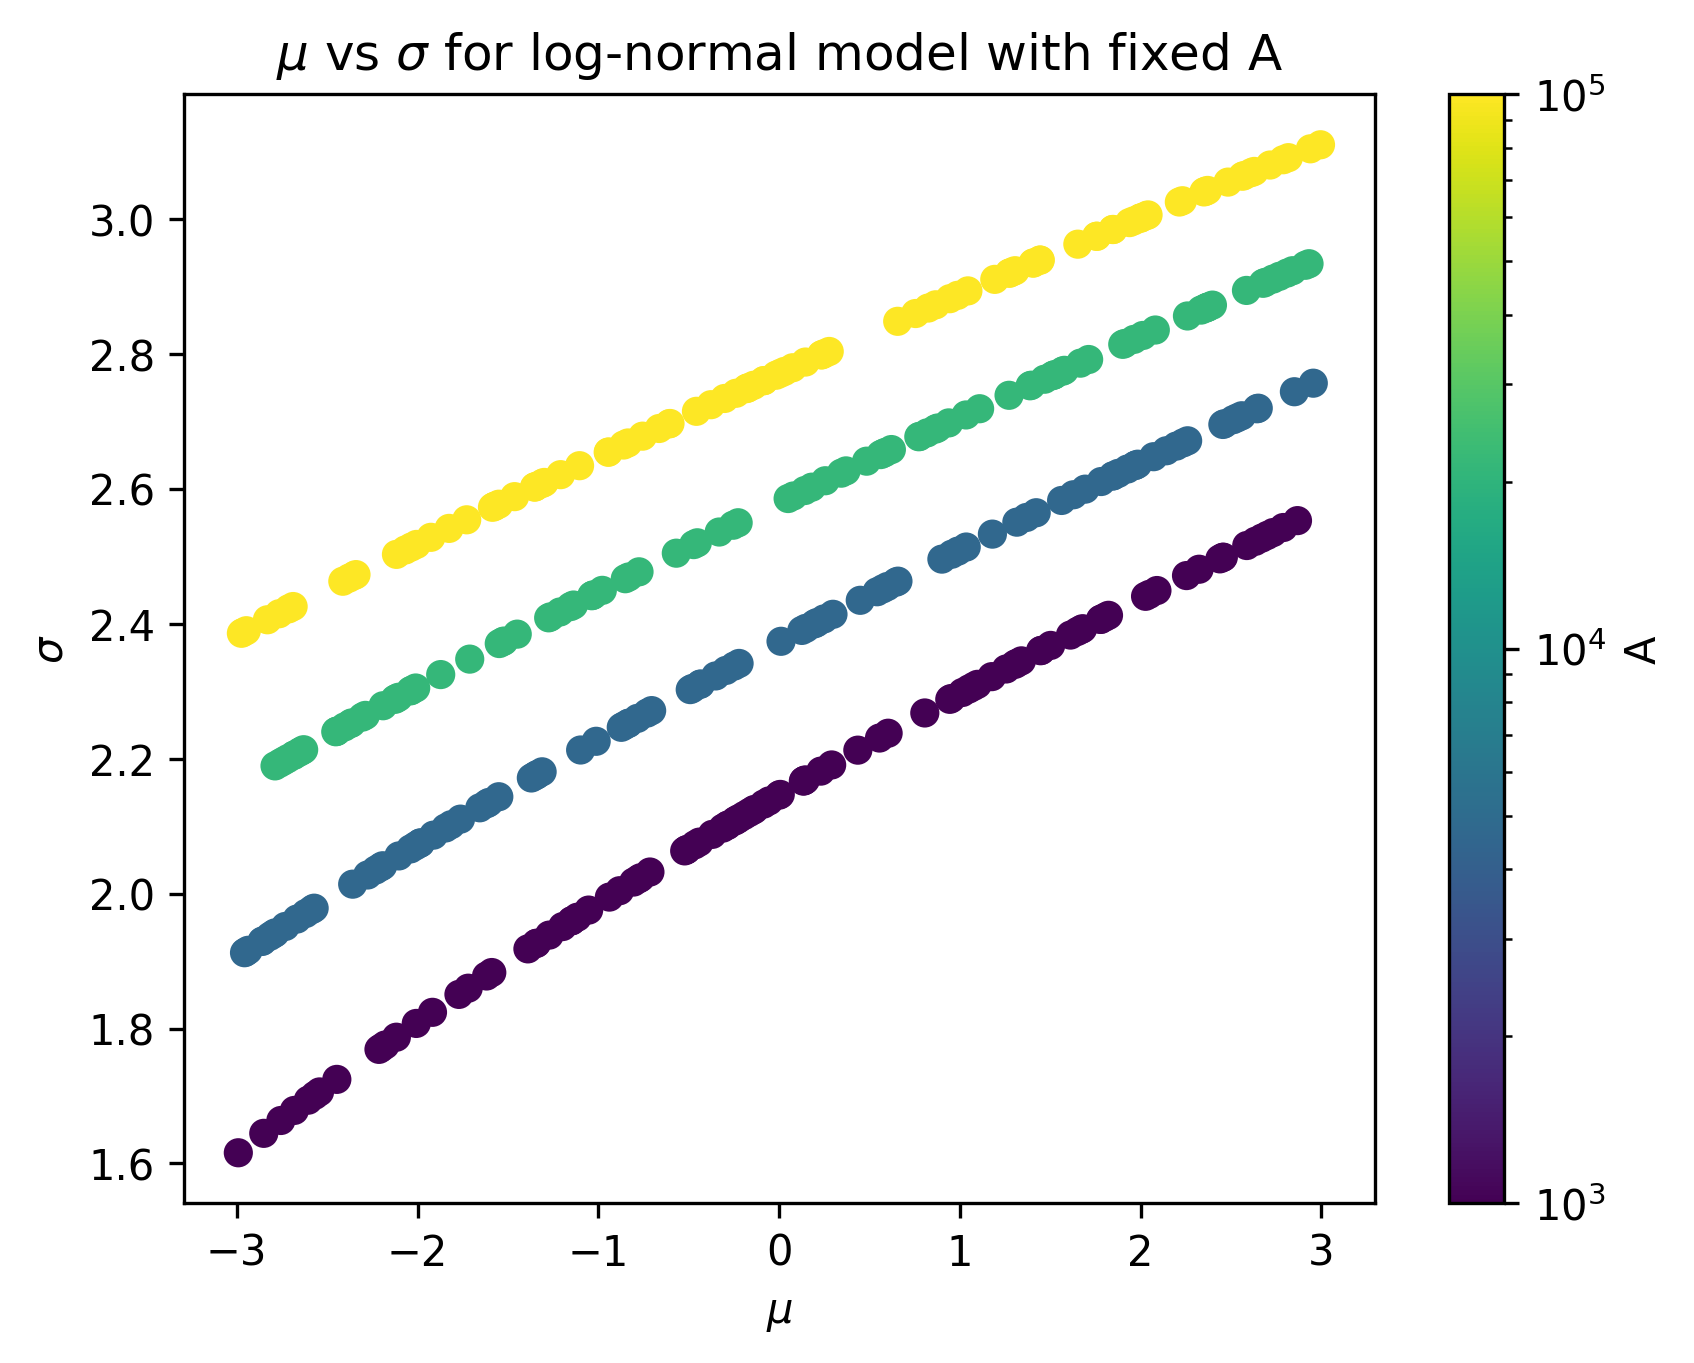

In [6]:
# In steady-state,
#   T = exp(-mu + sigma^2 / 2)
#   A = T exp(sigma^2).
# Therefore
#   sigma^2 = log(A) - log(T)
#   mu = sigma^2 / 2 - log(T)
# Combining these gives
#   mu = 3 sigma^2 / 2 - log(A)

# For fixed A, sample mu to calculate sigma
A_vals = np.logspace(3,5,num=4)
np.random.seed(7)
mus = np.random.uniform(-3, 3, size=(4, 100))
sigmas = np.sqrt(2 * (mus + np.log(A_vals[:, None])) / 3)

# Scatter coloring by A
fig, ax = plt.subplots(dpi=300)
scatter = ax.scatter(mus.flatten(), sigmas.flatten(), c=np.repeat(A_vals, 100), cmap='viridis', norm=LogNorm())
ax.set(xlabel='$\mu$', ylabel='$\sigma$', title='$\mu$ vs $\sigma$ for log-normal model with fixed A')
plt.colorbar(scatter, label='A') 



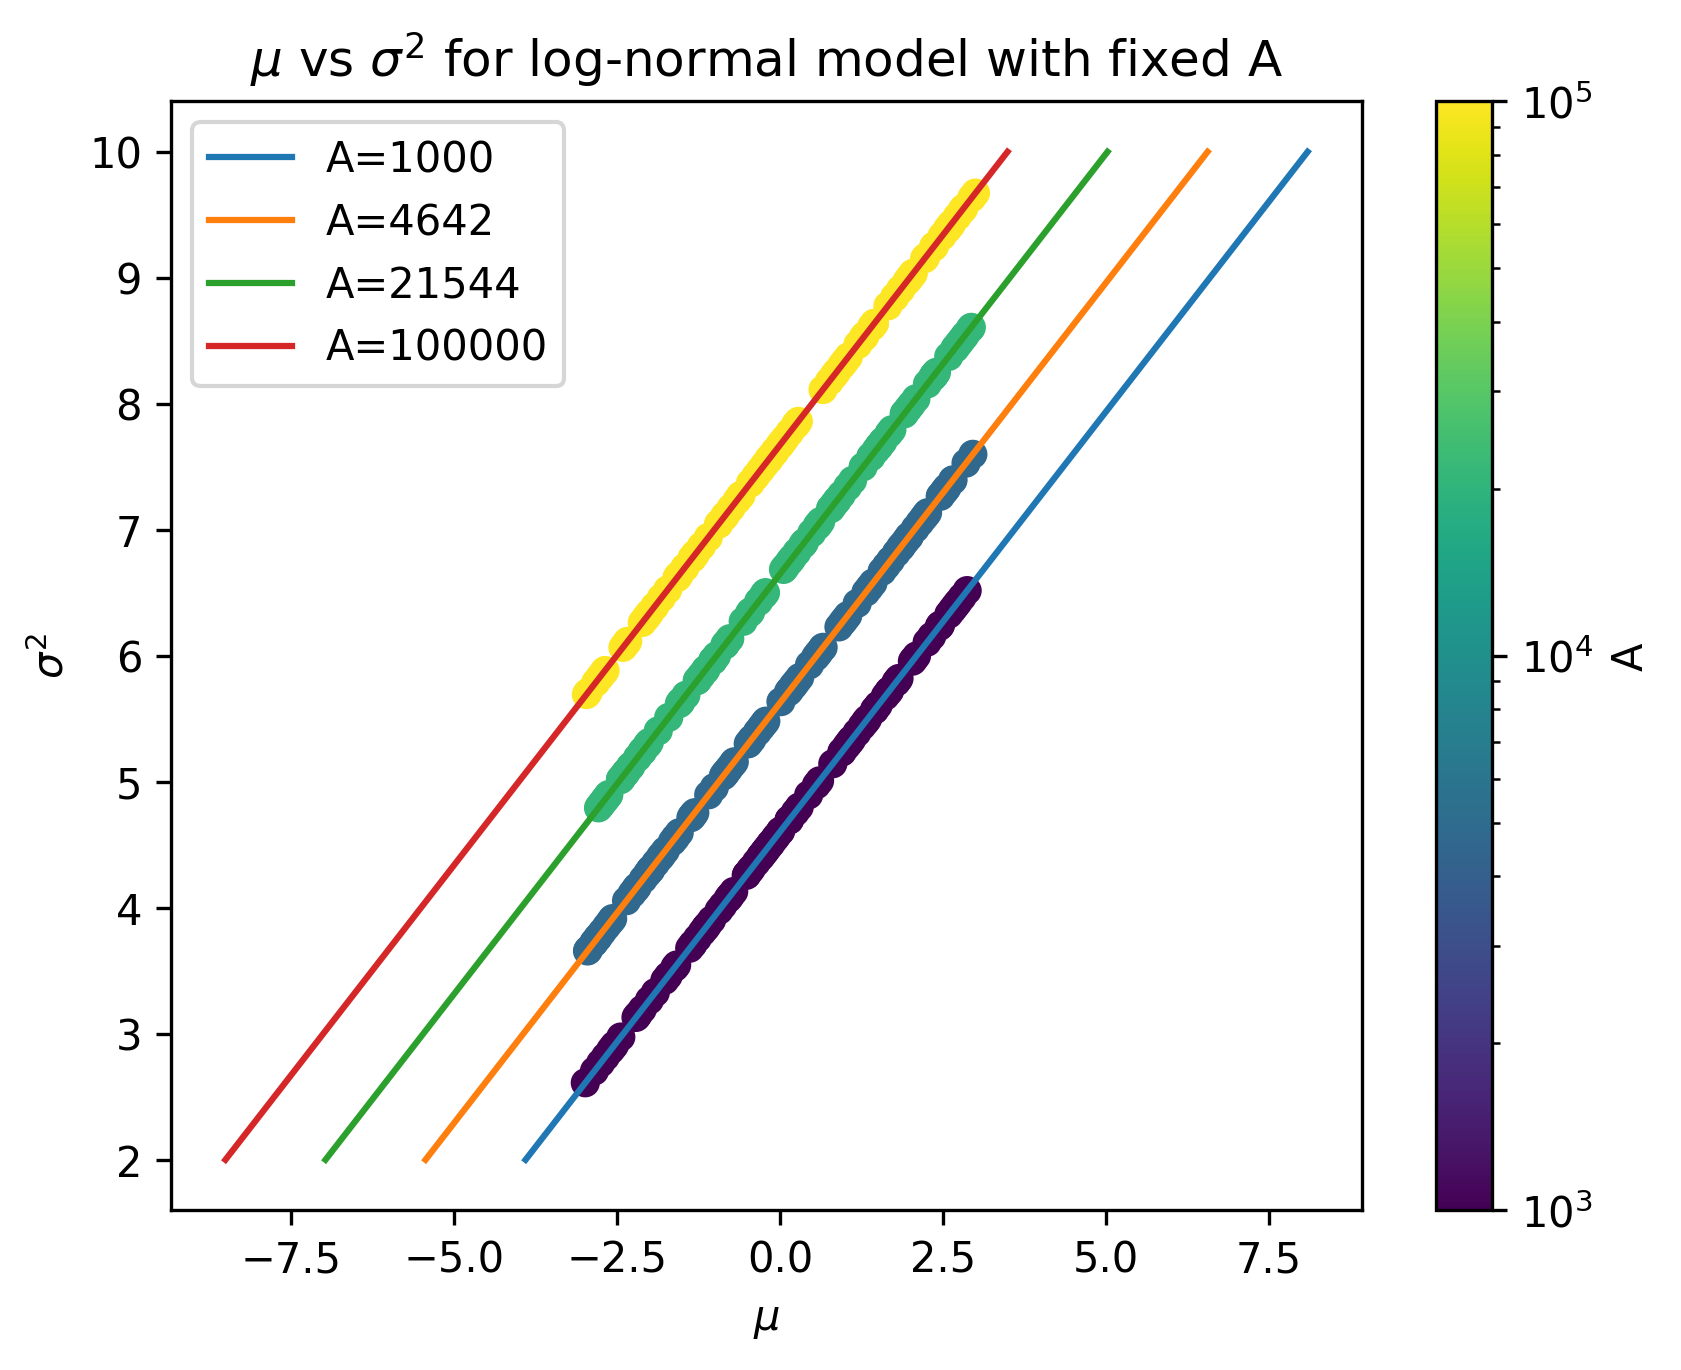

In [7]:
# Scatter mu against sigma^2, coloring by A to emphasize slope = 3/2
fig, ax = plt.subplots(dpi=300)
scatter = ax.scatter(mus.flatten(), sigmas.flatten()**2, c=np.repeat(A_vals, 100), cmap='viridis', norm=LogNorm())
ax.set(xlabel='$\mu$', ylabel='$\sigma^2$', title='$\mu$ vs $\sigma^2$ for log-normal model with fixed A')
# For each value of A, plot the line mu = 3 sigma^2 / 2 - log(A)
for A in A_vals:
    sigma2 = np.linspace(2, 10, 100)
    mu = 3 * sigma2 / 2 - np.log(A)
    ax.plot(mu, sigma2, label=f'A={A:.0f}')
ax.legend()
plt.colorbar(scatter, label='A')